## Figure 3: Heatmap (Atlas) ##
Heatmaps compiled using Supplementary File 6: Cytoskeleton_DIVs_summarystat.csv. This script contains two blocks for generating cytoskeletal heatmaps: 

Compiled Heatmap (all categories): 
plots all proteins in csv, may be used for cytoskeletal csvs or general lists

ProtClass Heatmap:
specifically calls proteins within specific atlas based on ProtClass column in Cytoskeletal csvs: MAP, Actin, Regulatory, Motor, PTM, IF, Nuclear, Septin, Spectrin, Tubulin, Cargo, Centrosome. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

In [3]:
askmastersheet = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askmastersheet, encoding='utf-8')
data

,DCX_DIV2_3,DCX_DIV2_1,DCX_DIV2_2,DCX_DIV3_2,DCX_DIV3_3,DCX_DIV3_1,DCX_DIV4_2,DCX_DIV4_3,DCX_DIV4_1,DCX_DIV5_3,...,Standard deviation DCX_DIV5,Valid values,Valid values DCX_DIV2,Valid values DCX_DIV3,Valid values DCX_DIV4,Valid values DCX_DIV5,Protein.Group,Protein.Ids,Genes,ProtClass
0,15.641337,15.893899,16.109905,15.221670,15.002354,14.744677,17.883825,17.439816,17.181133,15.708421,...,0.160629,13,3,3,3,4,P36873,P36873,PPP1CC,Regulatory
1,16.381990,16.050848,15.980740,15.520720,15.930804,16.057674,18.226049,17.956427,17.418257,17.365852,...,0.388595,13,3,3,3,4,P62136,P62136,PPP1CA,Regulatory
2,14.711737,14.087181,14.018157,12.823722,11.888941,13.194180,16.186760,15.401190,14.859166,15.809014,...,0.539714,13,3,3,3,4,P62140,P62140,PPP1CB,Regulatory
3,15.061861,15.666738,15.550028,13.860582,14.020737,14.406617,15.469521,15.526013,14.988086,15.116920,...,0.382210,17,3,3,3,4,Q9Y266,Q9Y266,NUDC,MAP
4,NaN,11.682411,11.045705,NaN,NaN,NaN,12.544216,13.280929,NaN,13.635707,...,0.537123,8,2,0,2,4,P42684,P42684,ABL2,MAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,12.169324,12.666861,12.682644,12.738861,13.040365,12.882186,13.217134,13.383906,13.770581,12.174314,...,0.585315,13,3,3,3,4,O94901,O94901,SUN1,Nuclear
248,14.947797,14.360161,14.348943,14.683691,15.138052,15.312071,14.351892,14.294865,15.024560,13.765659,...,1.125398,13,3,3,3,4,P02545,P02545,LMNA,Nuclear
249,15.767135,15.247935,15.722480,15.282408,15.981324,15.870441,15.650530,15.718707,15.899567,15.496302,...,0.349046,13,3,3,3,4,P20700,P20700,LMNB1,Nuclear
250,13.677665,14.205702,14.107610,13.787321,13.166529,14.009181,15.780717,15.574499,15.288145,14.935138,...,0.391118,13,3,3,3,4,P50402,P50402,EMD,Nuclear


In [4]:
#Create plots folder

pathmastersheet = Path(askmastersheet)
resultdirectory = str(pathmastersheet.parents[0])+'//Plots'
newmydir = Path(resultdirectory)
newmydir.mkdir(exist_ok=True)
path = newmydir
path

WindowsPath('C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/Curated_Cytoskeleton/Plots')

## Compiled Heatmap (all categories) ##

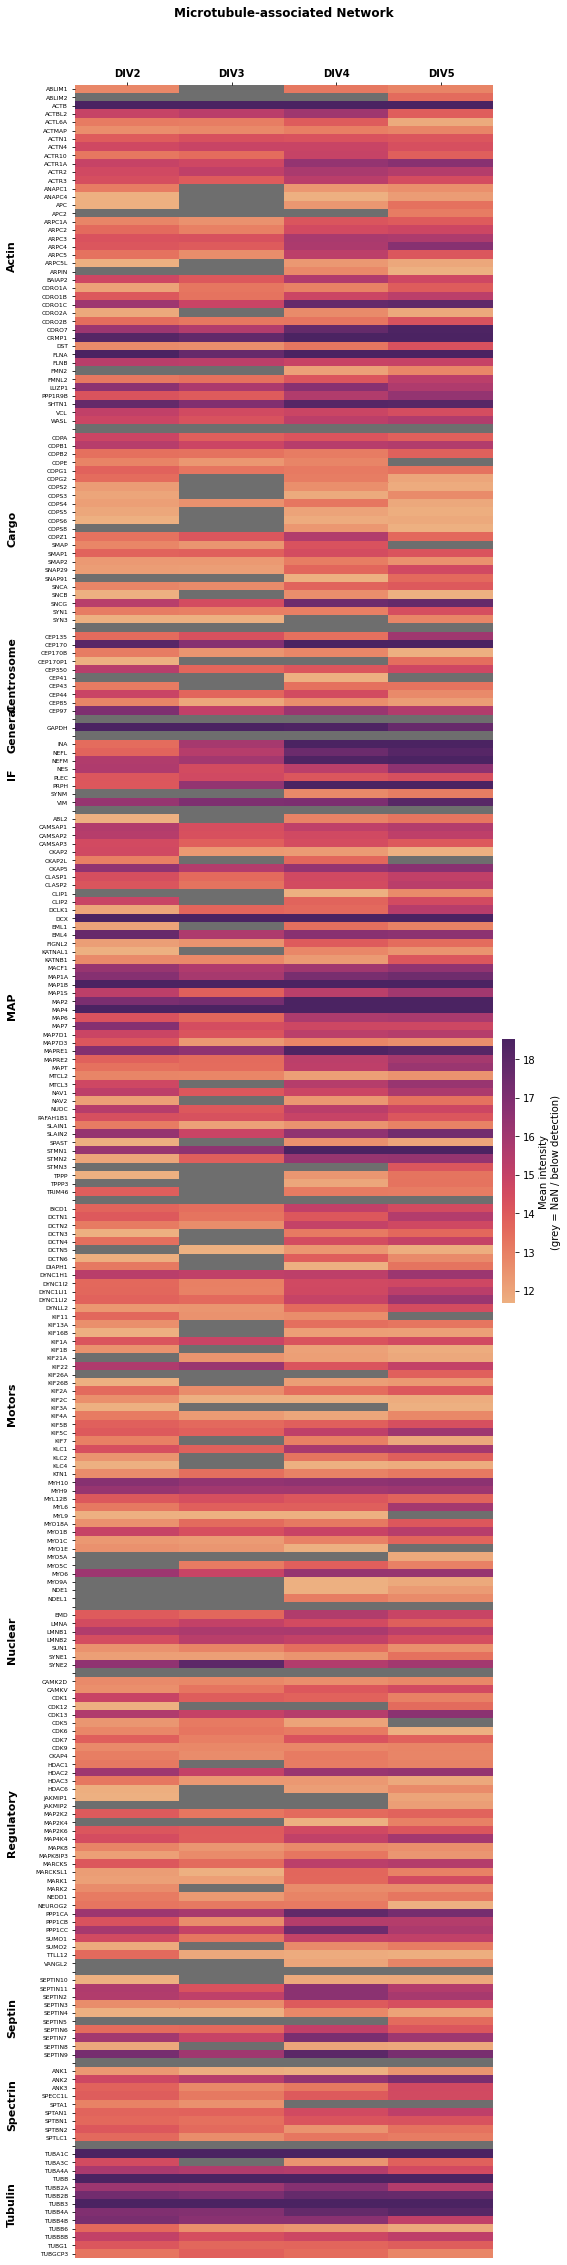

In [5]:
## Compiled Heatmap (all categories) --- check!

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import copy

df = data

# ----------------------------
# SETTINGS
# ----------------------------
gene_col   = "Genes"
class_col  = "ProtClass"
div_cols   = ["Mean DCX_DIV2", "Mean DCX_DIV3", "Mean DCX_DIV4", "Mean DCX_DIV5"]
valid_cols = ["Valid values DCX_DIV2", "Valid values DCX_DIV3", "Valid values DCX_DIV4", "Valid values DCX_DIV5"]
div_labels = ["DIV2", "DIV3", "DIV4", "DIV5"]

# ----------------------------
# CLEAN (NO REORDERING)
# ----------------------------
tmp = df[[gene_col, class_col] + div_cols + valid_cols].copy()
tmp[gene_col] = tmp[gene_col].astype(str).str.strip()

for c in div_cols + valid_cols:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

# nullify means where corresponding valid values < 2
for mean_col, valid_col in zip(div_cols, valid_cols):
    tmp.loc[tmp[valid_col] < 2, mean_col] = np.nan

# block labels come from ProtClass; NaNs become "Other"
tmp["_block"] = tmp[class_col].fillna("Other").astype(str)

# (optional) one row per gene (keeps first occurrence; preserves original order)
tmp = tmp.drop_duplicates(subset=[gene_col], keep="first")

# ----------------------------
# 🔥 ADDED: SORT BY ProtClass, THEN GENE (alphabetical within class)
# ----------------------------
tmp = tmp.sort_values(by=["_block", gene_col], kind="stable").copy()

# ----------------------------
# BUILD MATRIX (order preserved exactly as in tmp)
# ----------------------------
tmp["_row"] = np.arange(len(tmp))

plot_df = (
    tmp.set_index("_row")[div_cols]
       .rename(columns=dict(zip(div_cols, div_labels)))
)

gene_labels  = tmp.set_index("_row")[gene_col].astype(str)
group_labels = tmp.set_index("_row")["_block"].astype(str)

# ----------------------------
# COLOR RANGE (compute BEFORE adding gap rows)
# ----------------------------
vals = plot_df.to_numpy(dtype=float)
vmin = np.nanpercentile(vals, 5)
vmax = np.nanpercentile(vals, 95)

cmap = copy.copy(cm.get_cmap("flare"))
cmap.set_bad("#6e6e6e")  # real NaNs (missing/below detection) are grey
# cmap.set_bad("#ffffff")   # masked rows (gaps) appear white

# ----------------------------
# INSERT REAL WHITESPACE BETWEEN BLOCKS (masked gap rows)
# ----------------------------
g = group_labels.values
breaks = np.where(g[:-1] != g[1:])[0] + 1

gap_n = 1  # set to 2 for more whitespace

new_blocks = []
new_gene_labels = []
new_group_labels = []
gap_index = []

start = 0
for i, b in enumerate(list(breaks) + [len(g)]):
    # append real block
    new_blocks.append(plot_df.iloc[start:b])
    new_gene_labels.extend(gene_labels.iloc[start:b].tolist())
    new_group_labels.extend(group_labels.iloc[start:b].tolist())

    # append gap row(s) after each block except the last
    if b != len(g):
        for k in range(gap_n):
            gi = f"__gap_{i}_{k}"
            gap_index.append(gi)
            new_blocks.append(pd.DataFrame(np.nan, index=[gi], columns=plot_df.columns))
            new_gene_labels.append("")          # no gene label on whitespace rows
            new_group_labels.append("__gap__")  # sentinel
    start = b

plot_df = pd.concat(new_blocks)

# mask ONLY the gap rows so they render as true white whitespace
mask = pd.DataFrame(False, index=plot_df.index, columns=plot_df.columns)
mask.loc[gap_index, :] = True

# ----------------------------
# PLOT
# ----------------------------
fig_h = max(4, 0.12 * plot_df.shape[0])
plt.figure(figsize=(8, fig_h))

ax = sns.heatmap(
    plot_df,
    mask=mask,   # <-- gap rows become white space
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    linewidths=0,
    cbar_kws={
        "label": "Mean intensity\n(grey = NaN / below detection)",
        "fraction": 0.03,
        "pad": 0.02,
    }
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
plt.ylabel(" ")

# y tick labels (match expanded plot_df with gaps)
ax.set_yticks(np.arange(plot_df.shape[0]) + 0.5)
ax.set_yticklabels(new_gene_labels, fontsize=6)
plt.setp(ax.get_yticklabels(), rotation=0)

ax.tick_params(axis="x", labelsize=10)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

ax.set_title(
    "Microtubule-associated Network",
    fontweight="bold",
    pad=25,
    y=1.02
)

# ----------------------------
# BLOCK LABELS (account for gap rows)
# ----------------------------
ng = np.array(new_group_labels, dtype=object)
is_gap = (ng == "__gap__")

# find contiguous real blocks (ignoring gap rows)
real_idx = np.where(~is_gap)[0]
if real_idx.size > 0:
    block_starts = [real_idx[0]]
    block_ends = []

    for i in range(1, len(real_idx)):
        if real_idx[i] != real_idx[i - 1] + 1:
            block_ends.append(real_idx[i - 1] + 1)  # end is exclusive
            block_starts.append(real_idx[i])

    block_ends.append(real_idx[-1] + 1)

    for s, e in zip(block_starts, block_ends):
        label = ng[s]
        y = (s + e) / 2
        ax.text(
            -0.6, y, label,
            va="center", ha="center",
            rotation=90, fontsize=11, fontweight="bold"
        )

plt.tight_layout()
plt.savefig(path / f"HM_Compiled_{date}.svg")
plt.show()

## ProtClass heatmaps ##

In [6]:
## Heatmaps called by ProtClass

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import copy

def plot_protclass_heatmap(data, protclass_name, path, date):
    df = data

    # ----------------------------
    # SETTINGS
    # ----------------------------
    gene_col   = "Genes"
    class_col  = "ProtClass"
    div_cols   = ["Mean DCX_DIV2", "Mean DCX_DIV3", "Mean DCX_DIV4", "Mean DCX_DIV5"]
    valid_cols = ["Valid values DCX_DIV2", "Valid values DCX_DIV3", "Valid values DCX_DIV4", "Valid values DCX_DIV5"]
    div_labels = ["DIV2", "DIV3", "DIV4", "DIV5"]

    # ----------------------------
    # CLEAN + SORT
    # ----------------------------
    tmp = df[[gene_col, class_col] + div_cols + valid_cols].copy()
    tmp[gene_col] = tmp[gene_col].astype(str).str.strip()

    for c in div_cols + valid_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    # nullify means where corresponding valid values < 2
    for mean_col, valid_col in zip(div_cols, valid_cols):
        tmp.loc[tmp[valid_col] < 2, mean_col] = np.nan

    # block labels come from ProtClass; NaNs become "Other"
    tmp["_block"] = tmp[class_col].fillna("Other").astype(str)

    # one row per gene
    tmp = tmp.drop_duplicates(subset=[gene_col], keep="first")

    # sort by ProtClass, then gene alphabetically within class
    tmp = tmp.sort_values(by=["_block", gene_col], kind="stable").copy()

    # ----------------------------
    # KEEP ONLY REQUESTED ProtClass
    # ----------------------------
    tmp = tmp[tmp["_block"] == protclass_name].copy()

    if tmp.empty:
        raise ValueError(f"No rows found for ProtClass: {protclass_name}")

    # ----------------------------
    # BUILD MATRIX
    # ----------------------------
    tmp["_row"] = np.arange(len(tmp))

    plot_df = (
        tmp.set_index("_row")[div_cols]
           .rename(columns=dict(zip(div_cols, div_labels)))
    )

    gene_labels = tmp.set_index("_row")[gene_col].astype(str)

    # ----------------------------
    # COLOR RANGE
    # ----------------------------
    vals = plot_df.to_numpy(dtype=float)
    vmin = np.nanpercentile(vals, 5)
    vmax = np.nanpercentile(vals, 95)

    cmap = copy.copy(cm.get_cmap("flare"))
    cmap.set_bad("#6e6e6e")  # real NaNs (missing/below detection) are grey

    # ----------------------------
    # PLOT
    # ----------------------------
    fig_h = 0.3 * plot_df.shape[0]
    plt.figure(figsize=(8, fig_h))
    ax = sns.heatmap(

   
        plot_df,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
        cbar_kws={
            "label": "Mean intensity\n(grey = NaN / below detection)",
            "fraction": 0.03,
            "pad": 0.02,
        }
    )

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    plt.ylabel(" ")

    ax.set_yticks(np.arange(plot_df.shape[0]) + 0.5)
    ax.set_yticklabels(gene_labels, fontsize=6)
    plt.setp(ax.get_yticklabels(), rotation=0)

    ax.tick_params(axis="x", labelsize=10)
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    ax.set_title(
        protclass_name,
        fontweight="bold",
        pad=25,
        y=1.02
    )

    #plt.tight_layout()
    plt.savefig(path / f"HM_MAPs_{protclass_name}_{date}.svg")
    plt.show()

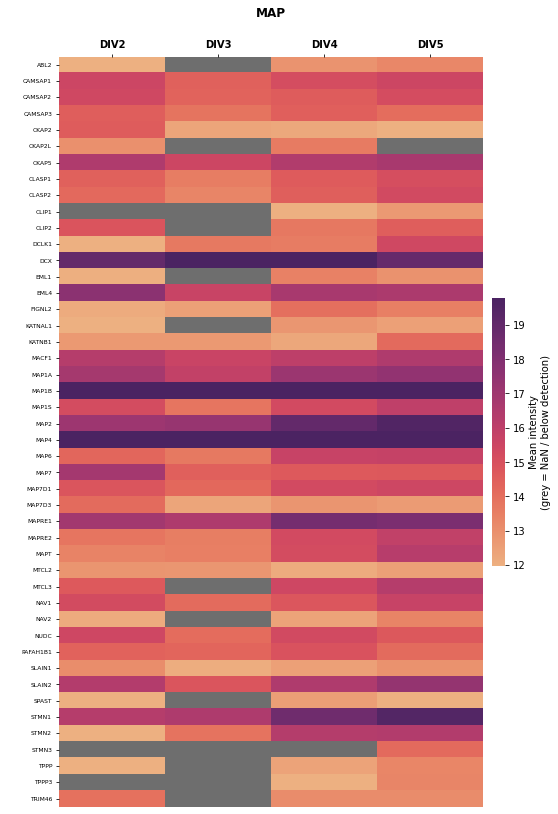

In [7]:
plot_protclass_heatmap(data, "MAP", path, date)